In [1]:
from pathlib import Path
import pandas as pd
import json
import re

DATA298_DIR = Path.home() / "Desktop" / "Data298"
IDFLAKIES_DIR = DATA298_DIR / "iDFlakies"

# Raw iDFlakies outputs
OUTPUT_DIR = (IDFLAKIES_DIR / "scripts" / "docker" / "all-output")

# Comprehensive-individual split input CSVs
INPUT_DIR = (IDFLAKIES_DIR / "scripts" / "docker" / "icst-dataset" / "comprehensive-individual-split")

# Cleaned data folder
CLEANED_DIR = (DATA298_DIR / "idflakies_analysis" / "cleaned_data")

CLEANED_DIR.mkdir(exist_ok=True)

print("Raw outputs:", OUTPUT_DIR)
print("Input CSVs:", INPUT_DIR)
print("Cleaned output:", CLEANED_DIR)

Raw outputs: /Users/sangah/Desktop/Data298/iDFlakies/scripts/docker/all-output
Input CSVs: /Users/sangah/Desktop/Data298/iDFlakies/scripts/docker/icst-dataset/comprehensive-individual-split
Cleaned output: /Users/sangah/Desktop/Data298/idflakies_analysis/cleaned_data


# Find flaky csv files

In [2]:
flaky_files = list(OUTPUT_DIR.glob("*_output/all_flaky_tests_list.csv"))

print("Projects with flaky-test CSV:", len(flaky_files))

Projects with flaky-test CSV: 1


# Observe how many projects output was produced

In [3]:
project_output_folders = list(
    OUTPUT_DIR.glob("*_output")
)

print("Project output folders:", len(project_output_folders))

for folder in project_output_folders:
    print(folder.name)

Project output folders: 9
abel533.mybatis-spring-boot_output
alibaba.fastjson_output
alibaba.arthas_output
alipay.sofa-boot_output
addthis.stream-lib_output
alipay.sofa-jarslink_output
activiti.activiti_output
kevinsawicki.http-request_output
alibaba.otter_output


# Make it easier to lookup metadata

In [4]:
import pandas as pd

project_metadata = {}

for csv_file in INPUT_DIR.glob("*.csv"):

    df = pd.read_csv(csv_file, header=None)

    project_name = csv_file.stem

    project_metadata[project_name.lower()] = {
        "repo_url": df.iloc[0, 0],
        "commit_sha": df.iloc[0, 1],
        "project_name": project_name,
        "source_split": "comprehensive"
    }

print("Metadata records:", len(project_metadata))

Metadata records: 183


# Take what we did for the example and bring it here to generalize it

In [6]:
records = []
missing_records = []

for flaky_csv in flaky_files:

    project_output_dir = flaky_csv.parent

    # Example:
    # kevinsawicki.http-request_output
    # -> kevinsawicki.http-request
    output_project_name = (
        project_output_dir.name
        .replace("_output", "")
    )

    # Find repo + commit metadata
    metadata = project_metadata.get(
        output_project_name.lower()
    )

    if metadata is None:
        print("Metadata not found:", output_project_name)
        continue

    # Read all_flaky_tests_list.csv
    df_flaky = pd.read_csv(
        flaky_csv,
        header=None,
        names=[
            "test_name",
            "detection_result_path"
        ]
    )

    for _, row in df_flaky.iterrows():

        test_name = row["test_name"]
        path = row["detection_result_path"]

        # Detector type
        detector_type = path.split("/")[3]

        # Round the number
        round_match = re.search(
            r"round(\d+)",
            path
        )

        if round_match is None:
            continue

        round_n = int(
            round_match.group(1)
        )

        # Open corresponding round JSON for the test
        json_path = (
            project_output_dir
            / path.replace("./", "")
        )

        if not json_path.exists():
            missing_records.append({
                "project_name": output_project_name,
                "test_name": test_name,
                "reason": "JSON not found"
            })
            continue

        with open(json_path, "r") as f:
            data = json.load(f)

        # Look for the test 
        filtered_dts = (
            data
            .get("filteredTests", {})
            .get("dts", [])
        )

        unfiltered_dts = (
            data
            .get("unfilteredTests", {})
            .get("dts", [])
        )

        match_found = None

        # Try finding it in filtered
        for dt in filtered_dts:
            if dt.get("name") == test_name:
                match_found = dt
                break

        # Try finding it in not filtered otherwise
        if match_found is None:
            for dt in unfiltered_dts:
                if dt.get("name") == test_name:
                    match_found = dt
                    break

        if match_found is None:
            missing_records.append({
                "project_name": output_project_name,
                "test_name": test_name,
                "reason": "Test not found in JSON"
            })
            continue

        intended = match_found["intended"]
        revealed = match_found["revealed"]

        intended_order = intended["order"]
        revealed_order = revealed["order"]

        records.append({
            "repo_url": metadata["repo_url"],
            "commit_sha": metadata["commit_sha"],
            "project_name": metadata["project_name"],
            "source_split": metadata["source_split"],
            "test_name": test_name,
            "detector_type": detector_type,
            "round": round_n,
            "flaky_type": match_found["type"],
            "intended_result": intended["result"],
            "revealed_result": revealed["result"],
            "intended_length": len(intended_order),
            "revealed_length": len(revealed_order),
            "length_diff": abs(len(revealed_order) - len(intended_order)),
            "round_time": data.get("roundTime"),
            "num_test_runs": len(
                data.get("testRunIds", [])
            )
        })

# Create dataframe for clean

In [8]:
detect_df = pd.DataFrame(records)

print("Detection records:", len(detect_df))
print("Unique project count:", detect_df["project_name"].nunique())
print("Unique tests:", detect_df["test_name"].nunique())

detect_df.head(15)

Detection records: 194
Unique project count: 1
Unique tests: 28


,repo_url,commit_sha,project_name,source_split,test_name,detector_type,round,flaky_type,intended_result,revealed_result,intended_length,revealed_length,length_diff,round_time,num_test_runs
0,https://github.com/kevinsawicki/http-request,2d62a3e9da726942a93cf16b6e91c0187e6c0136,kevinsawicki.http-request,comprehensive,com.github.kevinsawicki.http.HttpRequestTest.b...,random-class,1,OD,PASS,ERROR,27,135,108,31.044440,1
1,https://github.com/kevinsawicki/http-request,2d62a3e9da726942a93cf16b6e91c0187e6c0136,kevinsawicki.http-request,comprehensive,com.github.kevinsawicki.http.HttpRequestTest.b...,random-class,3,OD,PASS,ERROR,27,137,110,10.594816,1
2,https://github.com/kevinsawicki/http-request,2d62a3e9da726942a93cf16b6e91c0187e6c0136,kevinsawicki.http-request,comprehensive,com.github.kevinsawicki.http.HttpRequestTest.b...,random,1,OD,PASS,ERROR,27,116,89,24.485418,1
3,https://github.com/kevinsawicki/http-request,2d62a3e9da726942a93cf16b6e91c0187e6c0136,kevinsawicki.http-request,comprehensive,com.github.kevinsawicki.http.HttpRequestTest.b...,random,2,OD,PASS,ERROR,27,148,121,8.782828,1
4,https://github.com/kevinsawicki/http-request,2d62a3e9da726942a93cf16b6e91c0187e6c0136,kevinsawicki.http-request,comprehensive,com.github.kevinsawicki.http.HttpRequestTest.b...,random,5,OD,PASS,ERROR,27,91,64,4.266893,1
5,https://github.com/kevinsawicki/http-request,2d62a3e9da726942a93cf16b6e91c0187e6c0136,kevinsawicki.http-request,comprehensive,com.github.kevinsawicki.http.HttpRequestTest.b...,random,6,OD,PASS,ERROR,27,34,7,5.820044,1
6,https://github.com/kevinsawicki/http-request,2d62a3e9da726942a93cf16b6e91c0187e6c0136,kevinsawicki.http-request,comprehensive,com.github.kevinsawicki.http.HttpRequestTest.b...,random,8,OD,PASS,ERROR,27,139,112,8.302835,1
7,https://github.com/kevinsawicki/http-request,2d62a3e9da726942a93cf16b6e91c0187e6c0136,kevinsawicki.http-request,comprehensive,com.github.kevinsawicki.http.HttpRequestTest.b...,reverse,0,OD,PASS,ERROR,27,135,108,28.383681,1
8,https://github.com/kevinsawicki/http-request,2d62a3e9da726942a93cf16b6e91c0187e6c0136,kevinsawicki.http-request,comprehensive,com.github.kevinsawicki.http.HttpRequestTest.d...,random-class,1,OD,ERROR,PASS,38,124,86,31.044440,1
9,https://github.com/kevinsawicki/http-request,2d62a3e9da726942a93cf16b6e91c0187e6c0136,kevinsawicki.http-request,comprehensive,com.github.kevinsawicki.http.HttpRequestTest.d...,random-class,3,OD,ERROR,PASS,38,126,88,10.594816,1


# See label distribution

In [9]:
detect_df["flaky_type"].value_counts()

flaky_type
OD    194
Name: count, dtype: int64

# Detector Type

In [10]:
detect_df["detector_type"].value_counts()

detector_type
random          146
random-class     32
reverse          16
Name: count, dtype: int64

# Distribution by project

In [12]:
detect_df.groupby("project_name")["test_name"].nunique().sort_values(ascending=False)

project_name
kevinsawicki.http-request    28
Name: test_name, dtype: int64

# Check for null or duplicate rows

In [13]:
detect_df.isnull().sum()

repo_url           0
commit_sha         0
project_name       0
source_split       0
test_name          0
detector_type      0
round              0
flaky_type         0
intended_result    0
revealed_result    0
intended_length    0
revealed_length    0
length_diff        0
round_time         0
num_test_runs      0
dtype: int64

In [14]:
print("Duplicate rows:", detect_df.duplicated().sum())

Duplicate rows: 0


# Difference in detections

In [15]:
detect_df[
    [
        "intended_length",
        "revealed_length",
        "length_diff",
        "round_time",
        "num_test_runs"
    ]
].describe()

,intended_length,revealed_length,length_diff,round_time,num_test_runs
count,194.000000,194.000000,194.000000,194.000000,194.0
mean,85.164948,88.443299,40.876289,13.547760,1.0
std,35.475798,41.893640,33.534379,9.764490,0.0
min,27.000000,0.000000,0.000000,2.766909,1.0
25%,73.000000,64.250000,12.000000,5.583421,1.0
50%,78.000000,87.000000,31.000000,8.782828,1.0
75%,123.750000,121.750000,68.000000,24.485418,1.0
max,162.000000,162.000000,124.000000,31.044440,1.0


###

In [16]:
final_df = (
    detect_df
    .groupby(
        [
            "repo_url",
            "commit_sha",
            "project_name",
            "source_split",
            "test_name",
            "flaky_type"
        ],
        as_index=False
    )
    .agg(
        total_detection_count=("test_name", "size"),
        unique_detector_count=("detector_type", "nunique"),
        avg_intended_length=("intended_length", "mean"),
        avg_revealed_length=("revealed_length", "mean"),
        avg_length_diff=("length_diff", "mean"),
        avg_round_time=("round_time", "mean"),
        avg_num_test_runs=("num_test_runs", "mean")
    )
)

final_df.head(10)

,repo_url,commit_sha,project_name,source_split,test_name,flaky_type,total_detection_count,unique_detector_count,avg_intended_length,avg_revealed_length,avg_length_diff,avg_round_time,avg_num_test_runs
0,https://github.com/kevinsawicki/http-request,2d62a3e9da726942a93cf16b6e91c0187e6c0136,kevinsawicki.http-request,comprehensive,com.github.kevinsawicki.http.HttpRequestTest.b...,OD,8,3,27.0,116.875000,89.875000,15.210120,1.0
1,https://github.com/kevinsawicki/http-request,2d62a3e9da726942a93cf16b6e91c0187e6c0136,kevinsawicki.http-request,comprehensive,com.github.kevinsawicki.http.HttpRequestTest.d...,OD,9,3,38.0,82.000000,50.888889,15.089794,1.0
2,https://github.com/kevinsawicki/http-request,2d62a3e9da726942a93cf16b6e91c0187e6c0136,kevinsawicki.http-request,comprehensive,com.github.kevinsawicki.http.HttpRequestTest.d...,OD,7,3,39.0,90.142857,51.142857,14.648558,1.0
3,https://github.com/kevinsawicki/http-request,2d62a3e9da726942a93cf16b6e91c0187e6c0136,kevinsawicki.http-request,comprehensive,com.github.kevinsawicki.http.HttpRequestTest.d...,OD,10,3,40.0,92.700000,58.900000,14.139157,1.0
4,https://github.com/kevinsawicki/http-request,2d62a3e9da726942a93cf16b6e91c0187e6c0136,kevinsawicki.http-request,comprehensive,com.github.kevinsawicki.http.HttpRequestTest.d...,OD,9,3,41.0,87.888889,60.888889,14.248787,1.0
5,https://github.com/kevinsawicki/http-request,2d62a3e9da726942a93cf16b6e91c0187e6c0136,kevinsawicki.http-request,comprehensive,com.github.kevinsawicki.http.HttpRequestTest.g...,OD,9,3,73.0,67.000000,36.222222,15.286839,1.0
6,https://github.com/kevinsawicki/http-request,2d62a3e9da726942a93cf16b6e91c0187e6c0136,kevinsawicki.http-request,comprehensive,com.github.kevinsawicki.http.HttpRequestTest.g...,OD,10,3,74.0,90.500000,30.700000,14.007504,1.0
7,https://github.com/kevinsawicki/http-request,2d62a3e9da726942a93cf16b6e91c0187e6c0136,kevinsawicki.http-request,comprehensive,com.github.kevinsawicki.http.HttpRequestTest.g...,OD,9,3,75.0,79.666667,13.333333,15.089794,1.0
8,https://github.com/kevinsawicki/http-request,2d62a3e9da726942a93cf16b6e91c0187e6c0136,kevinsawicki.http-request,comprehensive,com.github.kevinsawicki.http.HttpRequestTest.g...,OD,9,3,76.0,74.000000,29.777778,14.984682,1.0
9,https://github.com/kevinsawicki/http-request,2d62a3e9da726942a93cf16b6e91c0187e6c0136,kevinsawicki.http-request,comprehensive,com.github.kevinsawicki.http.HttpRequestTest.g...,OD,8,3,77.0,89.000000,28.750000,16.470188,1.0


In [17]:
print(final_df.columns.tolist())

print("Final rows:", len(final_df))
print("Unique projects:", final_df["project_name"].nunique())
print("Unique tests:", final_df["test_name"].nunique())

print("\nMissing value total:")
print(final_df.isnull().sum())

print("\nDuplicate row total:")
print(final_df.duplicated().sum())

['repo_url', 'commit_sha', 'project_name', 'source_split', 'test_name', 'flaky_type', 'total_detection_count', 'unique_detector_count', 'avg_intended_length', 'avg_revealed_length', 'avg_length_diff', 'avg_round_time', 'avg_num_test_runs']
Final rows: 28
Unique projects: 1
Unique tests: 28

Missing value total:
repo_url                 0
commit_sha               0
project_name             0
source_split             0
test_name                0
flaky_type               0
total_detection_count    0
unique_detector_count    0
avg_intended_length      0
avg_revealed_length      0
avg_length_diff          0
avg_round_time           0
avg_num_test_runs        0
dtype: int64

Duplicate row total:
0


In [18]:
final_df.to_csv(CLEANED_DIR / "idflakies_clean.csv", index=False)
print("Saved to:", CLEANED_DIR / "idflakies_clean.csv") # If done successfully

Saved to: /Users/sangah/Desktop/Data298/idflakies_analysis/cleaned_data/idflakies_clean.csv


# Flaky test per project -- image

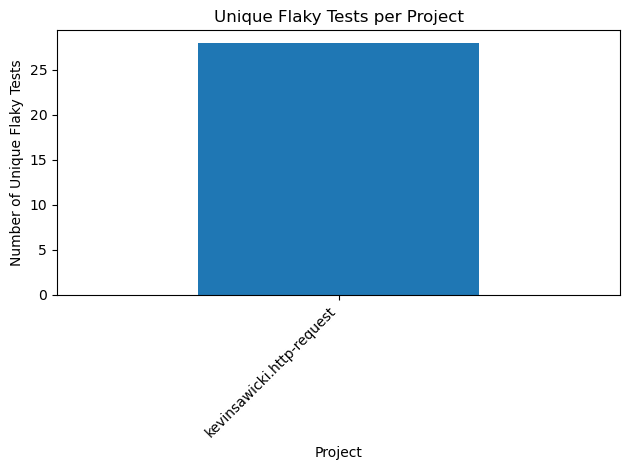

In [19]:
final_df["project_name"].value_counts().plot(kind="bar")

import matplotlib.pyplot as plt

plt.title("Unique Flaky Tests per Project")
plt.xlabel("Project")
plt.ylabel("Number of Unique Flaky Tests")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Detector distribution -- image

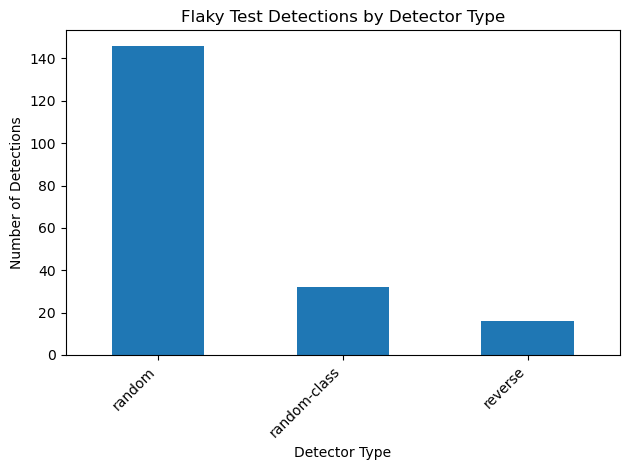

In [20]:
detect_df["detector_type"].value_counts().plot(kind="bar")

plt.title("Flaky Test Detections by Detector Type")
plt.xlabel("Detector Type")
plt.ylabel("Number of Detections")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()